# Analyse des features engineerées — Data Battle 2026

**Objectif** : Vérifier que les features construites dans `utils.py` apportent réellement de l'information sur `is_last_lightning_cloud_ground`, au-delà de l'inter-temps brut.

**Méthode** : Spearman + Information Mutuelle (MI) sur chaque feature, visualisations de distribution last vs non-last.

**Contexte EDA** :
- `inter_time_min` : seule feature brute informative (MI=1.0 normalisée, Pearson=0.31)
- Amplitude brute : plate tout au long de l'alerte → valeur uniquement dans les features dérivées
- Distance : courbe en U → la tendance/centroïde capturent la phase de sortie
- Toutes les autres features brutes : MI < 0.09

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '.')
from utils import compute_features, compute_surrounding_features

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 12
sns.set_style('whitegrid')
print('Librairies chargées ✓')

Librairies chargées ✓


In [2]:
df_raw = pd.read_csv(
    'data_train_databattle2026/segment_alerts_all_airports_train.csv',
    parse_dates=['date']
)
df_raw['date'] = pd.to_datetime(df_raw['date'], utc=True)

# Zone alerte uniquement (éclairs CG avec airport_alert_id)
df_alert = df_raw[df_raw['airport_alert_id'].notna()].copy()
df_alert['airport_alert_id'] = df_alert['airport_alert_id'].astype(int)

print(f'Éclairs CG en zone alerte : {len(df_alert):,}')
print(f'Shape brut : {df_raw.shape}')

Éclairs CG en zone alerte : 56,599
Shape brut : (507071, 13)


In [3]:
# Calcul des features via utils.py
df_feat = compute_features(df_alert)

# Normalisation de la cible
df_feat['target'] = df_feat['is_last_lightning_cloud_ground'].map(
    {'True': 1, 'False': 0, True: 1, False: 0}
).astype(int)

# Features construites disponibles
FEATURES = [
    # Inter-temps
    'inter_time_s', 'inter_time_log', 'ratio_median', 'ratio_mean',
    'ratio_max', 'z_score_inter', 'inter_trend', 'inter_accel',
    # Contexte alerte
    'n_cg_cumul', 'alert_dur_min',
    # Fenêtres glissantes
    'n_cg_5m', 'n_cg_10m', 'n_cg_15m',
    # Amplitude dérivée
    'amp_abs', 'is_positive', 'pct_pos_cumul', 'pct_pos_last5',
    'pct_pos_last10', 'amp_trend', 'amp_abs_trend',
    # Distance dérivée
    'mean_dist_5', 'mean_dist_10', 'dist_vs_mean5', 'dist_trend',
    'dist_is_increasing', 'az_dispersion',
    # Centroïde
    'centroid_dist_ap', 'centroid_speed', 'centroid_approach',
    'centroid_dist_trend',
    # Temporel
    'month', 'hour', 'season', 'airport_enc',
]

df_model = df_feat[FEATURES + ['target']].dropna()
print(f'Shape après features : {df_model.shape}')
print(f'Taux de cible (True) : {df_model["target"].mean()*100:.1f}%')

Shape après features : (56599, 35)
Taux de cible (True) : 4.6%


---
## 1. Ranking global : Spearman + Information Mutuelle

In [4]:
X = df_model[FEATURES].values
y = df_model['target'].values

from scipy.stats import kendalltau

# Spearman
sp = {f: abs(spearmanr(df_model[f], y).statistic) for f in FEATURES}
spearman = pd.Series(sp).sort_values(ascending=False)

# Kendall
kt = {f: abs(kendalltau(df_model[f], y).statistic) for f in FEATURES}
kendall = pd.Series(kt).sort_values(ascending=False)

# Information Mutuelle
mi_vals = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi_vals, index=FEATURES)
mi_norm = (mi / mi.max()).sort_values(ascending=False)

# Tableau récap
recap = pd.DataFrame({
    '|Spearman|':   spearman.round(4),
    '|Kendall|':    kendall.round(4),
    'MI normalisée': mi_norm.round(4),
    'Rang Spearman': spearman.rank(ascending=False).astype(int),
    'Rang MI':       mi_norm.rank(ascending=False).astype(int),
}).sort_values('MI normalisée', ascending=False)
recap['Rang moyen'] = ((recap['Rang Spearman'] + recap['Rang MI']) / 2).round(1)

print('=== Ranking des features par Information Mutuelle ===\n')
print(recap.to_string())

=== Ranking des features par Information Mutuelle ===

                     |Spearman|  |Kendall|  MI normalisée  Rang Spearman  Rang MI  Rang moyen
n_cg_10m                 0.3009     0.2485         1.0000              1        1         1.0
n_cg_5m                  0.2984     0.2486         0.9842              3        2         2.5
n_cg_15m                 0.2988     0.2460         0.9592              2        3         2.5
mean_dist_5              0.0921     0.0753         0.8960             12        4         8.0
mean_dist_10             0.0945     0.0772         0.8896             11        5         8.0
inter_time_s             0.0488     0.0402         0.7672             22        6        14.0
inter_trend              0.0649     0.0532         0.7606             18        7        12.5
inter_time_log           0.0488     0.0402         0.7600             22        8        15.0
n_cg_cumul               0.2628     0.2154         0.7367              4        9         6.5
inter

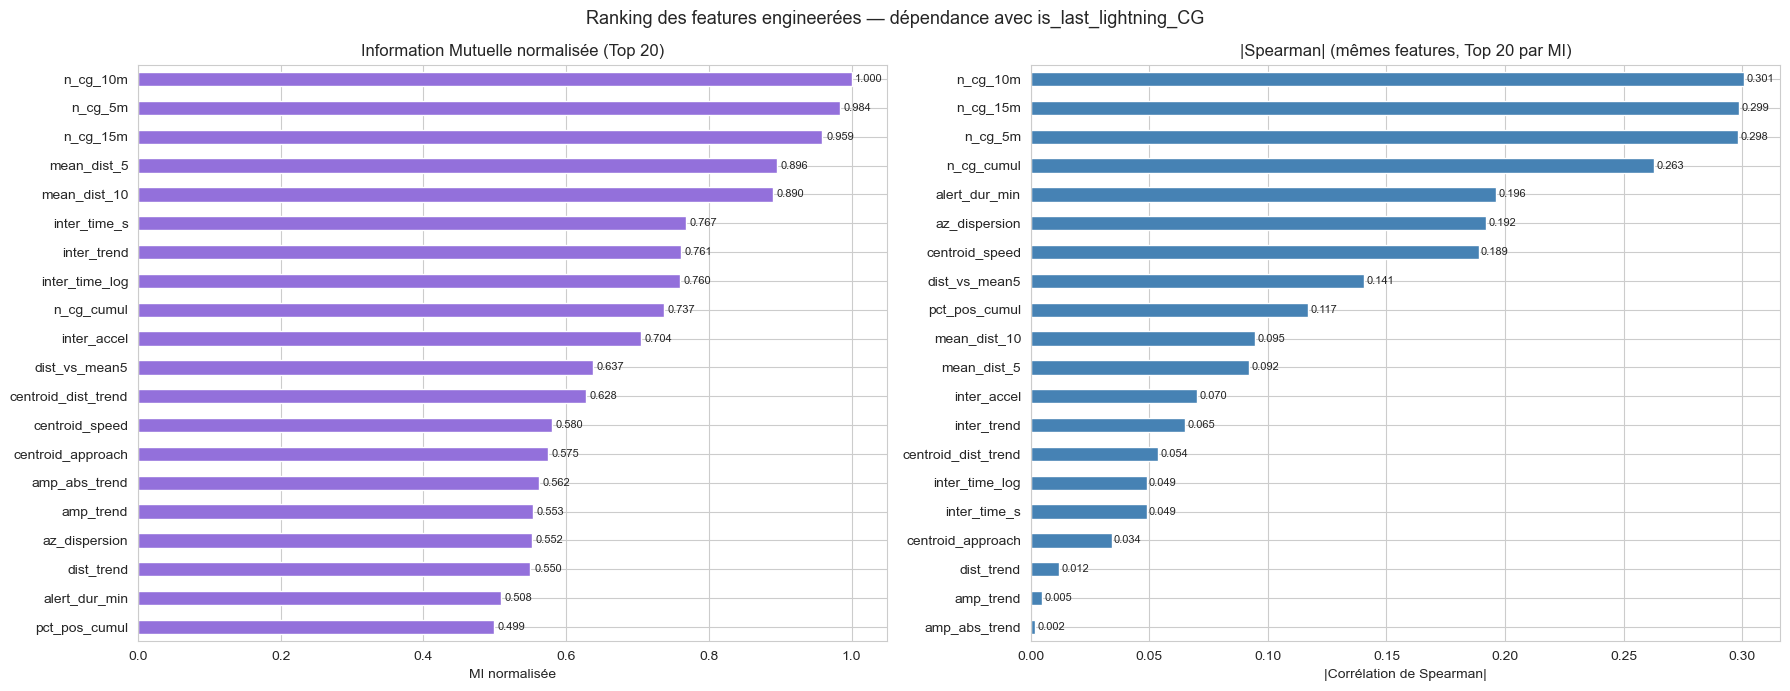

In [5]:
top_n = 20
top_feats = mi_norm.head(top_n)
sp_top = spearman[top_feats.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_feats.sort_values().plot(kind='barh', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title(f'Information Mutuelle normalisée (Top {top_n})')
axes[0].set_xlabel('MI normalisée')
for i, v in enumerate(top_feats.sort_values().values):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

sp_top.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title(f'|Spearman| (mêmes features, Top {top_n} par MI)')
axes[1].set_xlabel('|Corrélation de Spearman|')
for i, v in enumerate(sp_top.sort_values().values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Ranking des features engineerées — dépendance avec is_last_lightning_CG', fontsize=13)
plt.tight_layout()
plt.show()

### Interprétation du ranking global

**Top 3 incontestables — activité CG récente (n_cg_5m/10m/15m, MI~1.0, Spearman~0.30)**
Ces trois features dominent largement. Les distributions (section 5) le confirment visuellement : la distribution "last" est un **pic vertical à 0** — au dernier éclair, il ne s'est passé aucun CG dans les 5 à 15 minutes précédentes. C'est une règle quasi-déterministe. La Spearman~0.30 est élevée et cohérente entre les trois fenêtres.

**Distance (mean_dist_5/10, MI~0.89-0.90, Spearman~0.09)**
Forte MI mais Spearman faible → relation non-linéaire. La distance des derniers CG encode la **phase de l'orage** dans la zone alerte, pas une tendance monotone.

**Inter-temps (MI~0.70-0.77, Spearman~0.05-0.07)**
Signal non-linéaire : les distributions (section 2) montrent que la séparation n'existe que dans la **queue droite** (silences très longs). La masse principale des distributions se superpose. Le log atténue les extrêmes sans changer le rang (MI quasi identique à la valeur brute).

**amp_abs_trend / amp_trend (MI~0.55-0.56, Spearman ≈ 0)**
Paradoxe visible dans les graphiques (section 4) : les deux distributions sont visuellement **quasi identiques** (pics à 0, mêmes queues). La MI non nulle vient d'un signal infime dans les queues extrêmes. Très peu fiable en pratique — à surveiller en validation.

**Features clairement faibles — hour, is_positive, ratio_max/median/mean**
Visuellement : distributions last et non-last superposées ou presque. Peu de valeur ajoutée pour la modélisation.

---
## 2. Distribution last vs non-last — features inter-temps

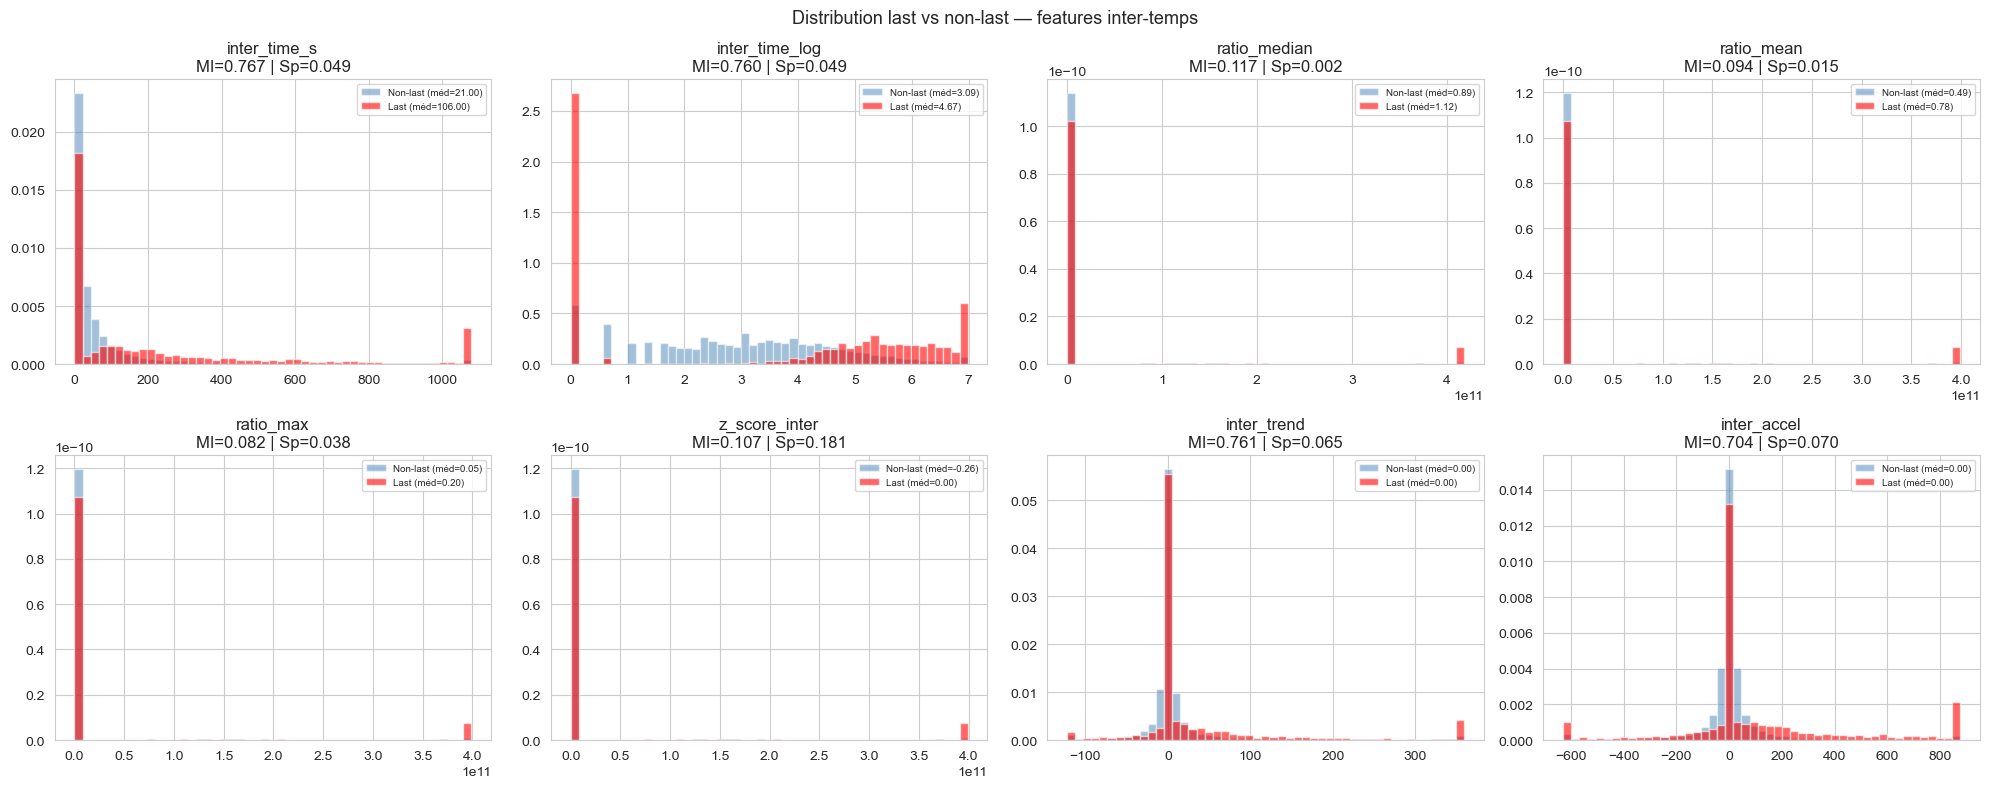

In [6]:
last     = df_model[df_model['target'] == 1]
non_last = df_model[df_model['target'] == 0]

inter_feats = ['inter_time_s', 'inter_time_log', 'ratio_median', 'ratio_mean',
               'ratio_max', 'z_score_inter', 'inter_trend', 'inter_accel']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(inter_feats):
    q99 = df_model[feat].quantile(0.99)
    q01 = df_model[feat].quantile(0.01)
    bins = np.linspace(q01, q99, 50)
    axes[i].hist(non_last[feat].clip(q01, q99), bins=bins, alpha=0.5, color='steelblue',
                 density=True, label=f'Non-last (méd={non_last[feat].median():.2f})')
    axes[i].hist(last[feat].clip(q01, q99),     bins=bins, alpha=0.6, color='red',
                 density=True, label=f'Last (méd={last[feat].median():.2f})')
    mi_val = mi_norm.get(feat, 0)
    sp_val = spearman.get(feat, 0)
    axes[i].set_title(f'{feat}\nMI={mi_val:.3f} | Sp={sp_val:.3f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribution last vs non-last — features inter-temps', fontsize=13)
plt.tight_layout()
plt.show()

### Interprétation — inter-temps

- **inter_time_s / inter_time_log** : les distributions montrent que la séparation est entièrement **dans la queue droite**. Non-last est massivement concentré à 0–100 s ; last a une queue s'étirant jusqu'à ~1000 s (médiane last ~108 s vs non-last ~21 s). Le signal existe mais n'est visible que pour les silences extrêmement longs.
- **ratio_median, ratio_mean, ratio_max** : visuellement **indiscernables** entre last et non-last (les deux classes ont le même pic à ~0, les mêmes queues). MI < 0.12 confirmé. Normaliser l'inter-temps par son passé détruit le signal : ce qui compte c'est la **valeur absolue** du silence, pas son ratio relatif.
- **z_score_inter** : Spearman=0.181 mais MI=0.107. Les distributions se superposent presque complètement. Peut-être utile marginalement en régression logistique (signal linéaire faible).
- **inter_trend** : les deux distributions sont très étroitement superposées autour de 0. Les valeurs positives extrêmes (silences qui s'allongent) sont légèrement plus fréquentes pour "last", mais c'est difficile à percevoir visuellement.
- **inter_accel** : même constat que inter_trend — distributions symétriques autour de 0, quasi identiques entre les classes.

---
## 3. Distribution last vs non-last — features distance & centroïde

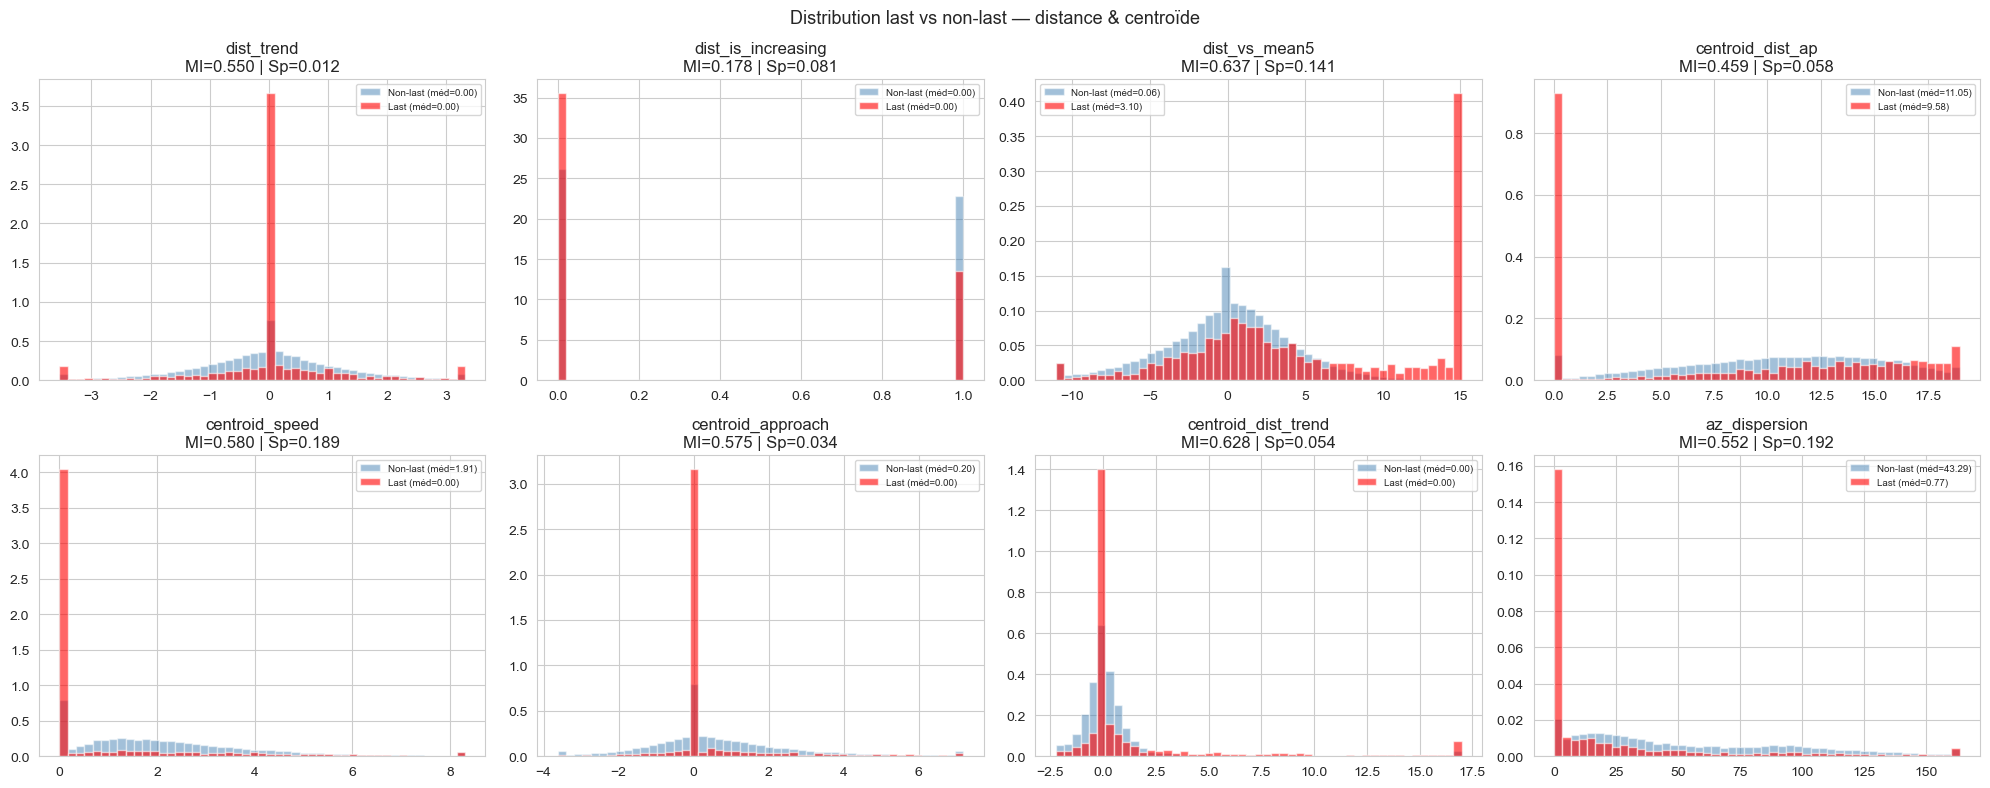

In [7]:
dist_feats = ['dist_trend', 'dist_is_increasing', 'dist_vs_mean5',
              'centroid_dist_ap', 'centroid_speed', 'centroid_approach', 'centroid_dist_trend',
              'az_dispersion']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(dist_feats):
    q99 = df_model[feat].quantile(0.99)
    q01 = df_model[feat].quantile(0.01)
    bins = np.linspace(q01, q99, 50)
    axes[i].hist(non_last[feat].clip(q01, q99), bins=bins, alpha=0.5, color='steelblue',
                 density=True, label=f'Non-last (méd={non_last[feat].median():.2f})')
    axes[i].hist(last[feat].clip(q01, q99),     bins=bins, alpha=0.6, color='red',
                 density=True, label=f'Last (méd={last[feat].median():.2f})')
    mi_val = mi_norm.get(feat, 0)
    sp_val = spearman.get(feat, 0)
    axes[i].set_title(f'{feat}\nMI={mi_val:.3f} | Sp={sp_val:.3f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribution last vs non-last — distance & centroïde', fontsize=13)
plt.tight_layout()
plt.show()

### Interprétation — distance & centroïde

- **az_dispersion** : **signal le plus visuellement clair de ce groupe**. Non-last : distribution étalée, médiane ~41° → l'orage actif frappe dans plusieurs directions. Last : distribution concentrée à ~0°, médiane ~0.77° → à la fin, les CG se regroupent dans une seule direction (orage qui se resserre ou se retire). Spearman=0.192 et visible à l'œil.
- **centroid_speed** : non-last médiane=1.97, last médiane=0.09 → le cœur orageux est quasi-immobile au dernier éclair. Distribution last très piquée à 0. Signal visuellement net.
- **dist_vs_mean5** : non-last piqué à 0 (l'éclair est à la distance moyenne), last a une légère queue positive (l'éclair est **plus loin** que la moyenne récente → phase de sortie). Visible mais subtil.
- **centroid_dist_ap** : médiane non-last=11.05 km, last=9.58 km → le centroïde est en réalité **légèrement plus près** de l'aéroport au dernier éclair. Contre-intuitif, mais les alertes courtes (cluster 0/3) ont souvent leur seul CG proche. Relation non-linéaire.
- **centroid_dist_trend** : les deux distributions sont très piquées à 0 avec queues symétriques. Signal non-linéaire dans les cas extrêmes seulement.
- **dist_trend** : distributions quasi identiques, pic à 0. Peu discriminant visuellement malgré MI=0.55.
- **dist_is_increasing** : non-last ~0.4 de 1s, last ~0.3 de 1s. Différence marginale.
- **centroid_approach** : les deux classes très concentrées à 0. Le vecteur de déplacement du centroïde est presque nul dans les deux cas.

---
## 4. Distribution last vs non-last — features amplitude

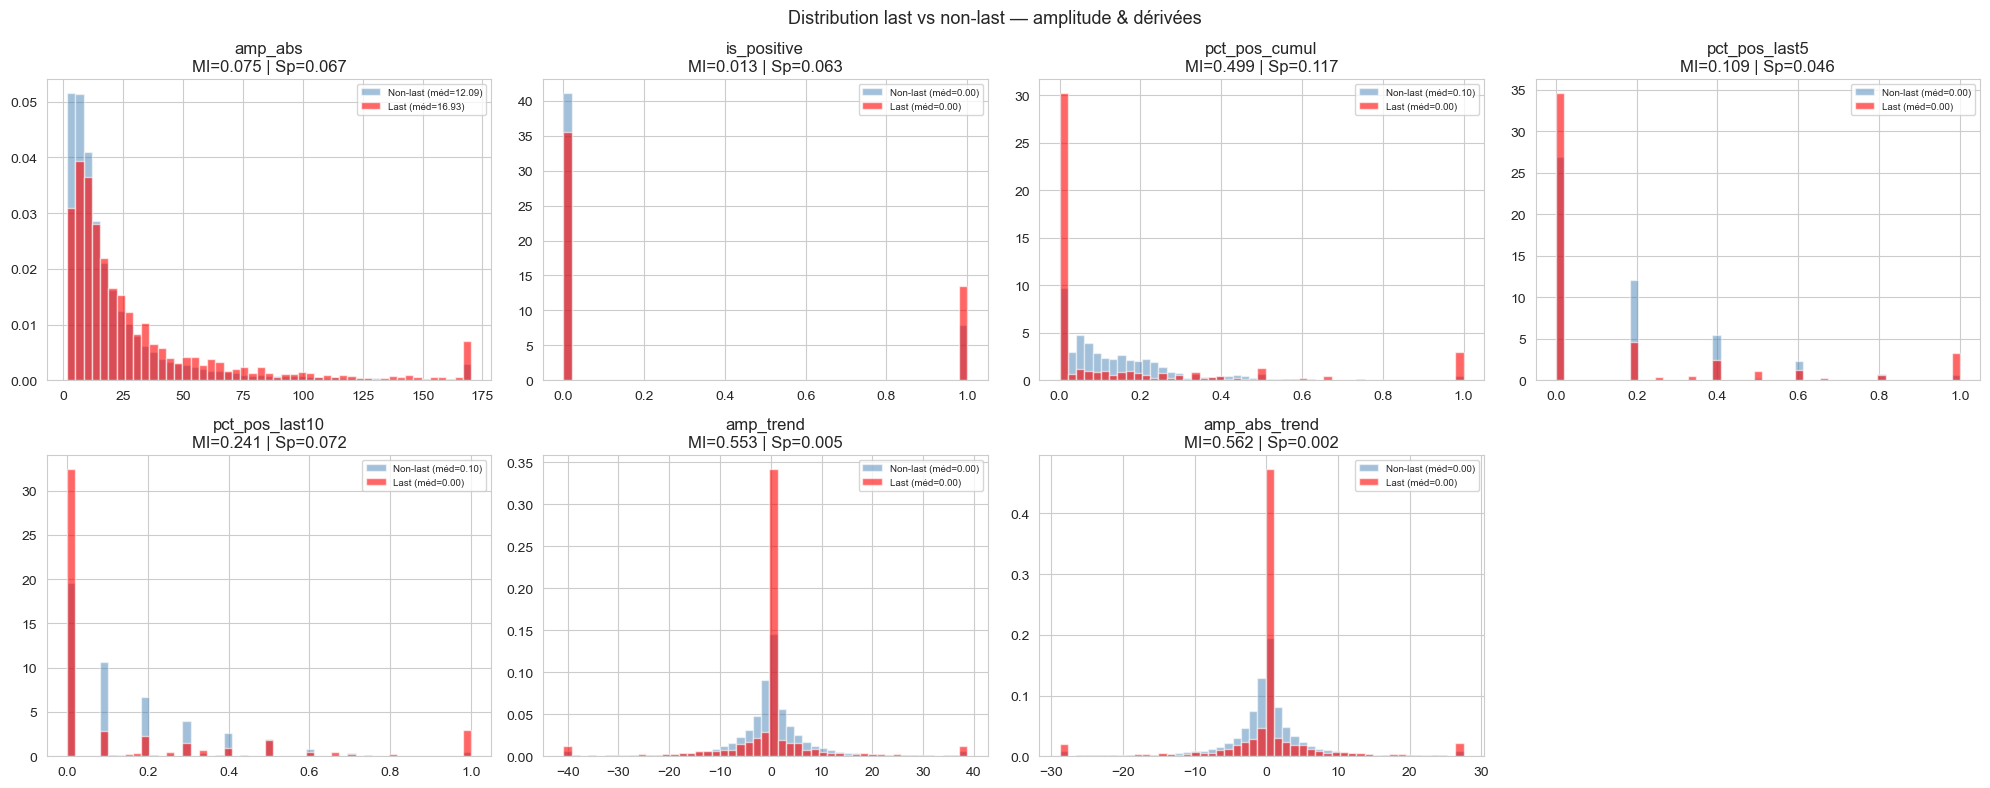

In [8]:
amp_feats = ['amp_abs', 'is_positive', 'pct_pos_cumul', 'pct_pos_last5',
             'pct_pos_last10', 'amp_trend', 'amp_abs_trend']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(amp_feats):
    q99 = df_model[feat].quantile(0.99)
    q01 = df_model[feat].quantile(0.01)
    bins = np.linspace(q01, q99, 50)
    axes[i].hist(non_last[feat].clip(q01, q99), bins=bins, alpha=0.5, color='steelblue',
                 density=True, label=f'Non-last (méd={non_last[feat].median():.2f})')
    axes[i].hist(last[feat].clip(q01, q99),     bins=bins, alpha=0.6, color='red',
                 density=True, label=f'Last (méd={last[feat].median():.2f})')
    mi_val = mi_norm.get(feat, 0)
    sp_val = spearman.get(feat, 0)
    axes[i].set_title(f'{feat}\nMI={mi_val:.3f} | Sp={sp_val:.3f}')
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Distribution last vs non-last — amplitude & dérivées', fontsize=13)
plt.tight_layout()
plt.show()

### Interprétation — amplitude

- **amp_abs** : distributions visuellement très similaires (médiane last=10.93 vs non-last=13.09 kA, légère différence). Confirme l'EDA : l'amplitude instantanée est plate. MI=0.075.
- **amp_trend / amp_abs_trend** : **paradoxe MI vs visuel** — malgré MI=0.55 et 0.56, les distributions sont visuellement **quasi identiques** : deux pics très étroits à 0 avec queues symétriques, médianes identiques (0.02/0.00 vs 0.03/0.00). La MI capture un signal infime dans les toutes dernières valeurs des queues. Ces features sont **à risque de surapprentissage** sur les arbres — surveiller en validation croisée.
- **pct_pos_cumul** : non-last piqué à 0 avec décroissance rapide, last similaire mais légèrement plus de masse aux valeurs intermédiaires (0.2–0.6). Médiane last=0.03 vs non-last=0.03 — différence à peine perceptible. Signal présent mais faible.
- **is_positive** : médiane non-last=0.013, last=0.022 → légèrement plus de CG positifs au dernier éclair, mais distributions presque superposées. Graphiquement : last a un pic plus marqué à 1.0. Signal très faible (MI=0.013).
- **pct_pos_last5 / pct_pos_last10** : mêmes médianes (0.00 vs 0.00). Distributions indiscernables visuellement. À exclure.

---
## 5. Distribution last vs non-last — fenêtres glissantes & contexte

---
## 5b. Features IC et CG entourant (`compute_surrounding_features`) + Storm cluster

Ces features capturent le **contexte électrique au-delà de la zone alerte** (0–30 km) :
- `n_ic_{5m/15m/30m}` : éclairs intra-nuage (IC) — précèdent et suivent l'arc en retour
- `n_cg_surr_{5m/15m/30m}` : CG dans la couronne 20–30 km
- `ratio_surr_{w}m` : IC/(IC+CG) → décroît à la fin de la cellule orageuse (signal physique fort)
- `storm_cluster` : type d'orage (K-Means 4 clusters sur features agrégées par alerte)

In [12]:
# ── Calcul des surrounding features (nécessite df_raw complet) ──────────────
df_surr = compute_surrounding_features(df_alert.copy(), df_raw)

# ── Storm cluster ────────────────────────────────────────────────────────────
# df_feat est déjà calculé dans la cellule précédente — on l'utilise directement
from utils import cluster_storms
df_feat_clust = cluster_storms(df_feat.copy())

# storm_cluster est au niveau alerte → merge sur airport + airport_alert_id uniquement
storm_map = (
    df_feat_clust[['airport', 'airport_alert_id', 'storm_cluster']]
    .drop_duplicates(subset=['airport', 'airport_alert_id'])
)
df_surr = df_surr.merge(storm_map, on=['airport', 'airport_alert_id'], how='left')
df_surr['storm_cluster'] = df_surr['storm_cluster'].fillna(0).astype(int)

# Cible
df_surr['target'] = df_surr['is_last_lightning_cloud_ground'].map(
    {'True': 1, 'False': 0, True: 1, False: 0}
).astype(int)

SURR_FEATS = [
    'n_ic_5m', 'n_ic_15m', 'n_ic_30m',
    'n_cg_surr_5m', 'n_cg_surr_15m', 'n_cg_surr_30m',
    'ratio_surr_5m', 'ratio_surr_15m', 'ratio_surr_30m',
    'storm_cluster',
]

df_surr_model = df_surr[SURR_FEATS + ['target']].dropna()
print(f'Shape après surrounding features : {df_surr_model.shape}')
print(f'Taux de cible (True) : {df_surr_model["target"].mean()*100:.1f}%')

=== Clusters d'orages (train ≤ 2020) ===
  Cluster 0 (n=328) : durée=4min, n_CG=1, inter_med=31s, dist=9.0km, heure=13h
  Cluster 1 (n=791) : durée=55min, n_CG=25, inter_med=191s, dist=13.5km, heure=12h
  Cluster 2 (n= 44) : durée=227min, n_CG=412, inter_med=23s, dist=13.2km, heure=10h
  Cluster 3 (n=866) : durée=6min, n_CG=2, inter_med=59s, dist=17.2km, heure=12h
Shape après surrounding features : (56599, 11)
Taux de cible (True) : 4.6%


=== Ranking surrounding features + storm_cluster ===

                |Spearman|  |Kendall|  MI normalisée
storm_cluster       0.0273     0.0265         1.0000
n_ic_15m            0.2608     0.2140         0.7070
n_ic_5m             0.2609     0.2152         0.6812
n_ic_30m            0.2549     0.2087         0.6735
n_cg_surr_30m       0.2508     0.2066         0.6552
ratio_surr_5m       0.2244     0.1848         0.6397
ratio_surr_15m      0.1966     0.1611         0.5920
n_cg_surr_15m       0.2438     0.2023         0.5880
ratio_surr_30m      0.1735     0.1420         0.5327
n_cg_surr_5m        0.2254     0.1911         0.4979


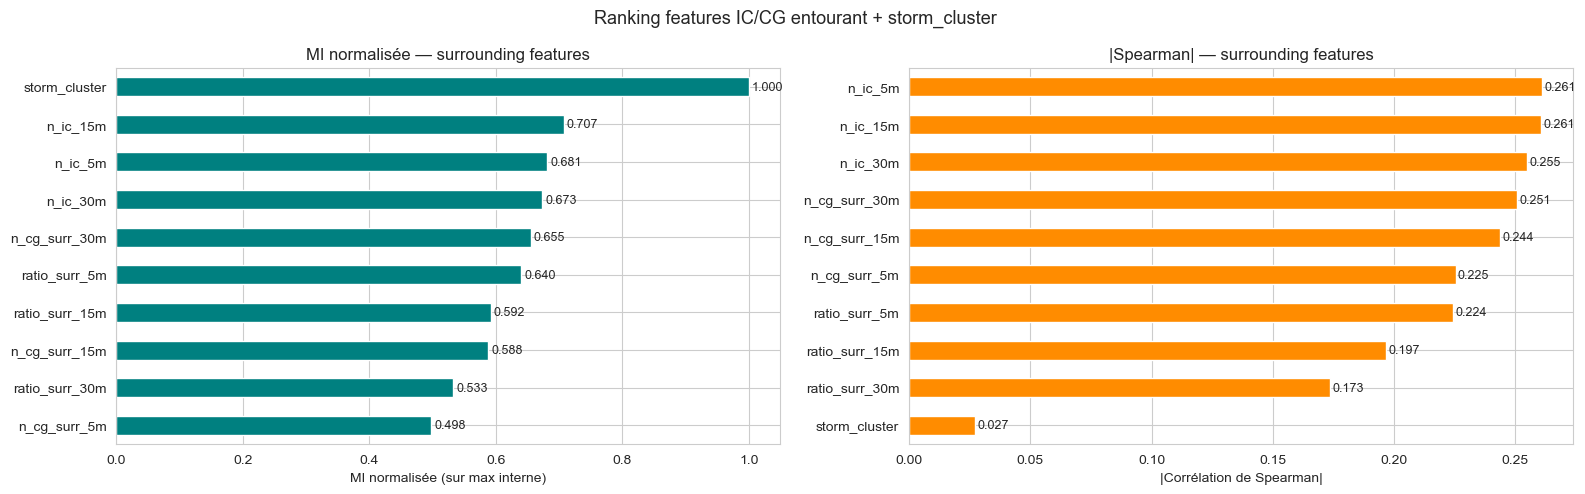

In [10]:
# ── Spearman + Kendall + MI pour les surrounding features ────────────────────
X_surr = df_surr_model[SURR_FEATS].values
y_surr = df_surr_model['target'].values

sp_surr = {f: abs(spearmanr(df_surr_model[f], y_surr).statistic) for f in SURR_FEATS}
spearman_surr = pd.Series(sp_surr).sort_values(ascending=False)

kt_surr = {f: abs(kendalltau(df_surr_model[f], y_surr).statistic) for f in SURR_FEATS}
kendall_surr = pd.Series(kt_surr).sort_values(ascending=False)

mi_surr_vals = mutual_info_classif(X_surr, y_surr, random_state=42)
mi_surr = pd.Series(mi_surr_vals, index=SURR_FEATS)
mi_surr_norm = (mi_surr / mi_surr.max()).sort_values(ascending=False)

recap_surr = pd.DataFrame({
    '|Spearman|':    spearman_surr.round(4),
    '|Kendall|':     kendall_surr.round(4),
    'MI normalisée': mi_surr_norm.round(4),
}).sort_values('MI normalisée', ascending=False)
print('=== Ranking surrounding features + storm_cluster ===\n')
print(recap_surr.to_string())

# ── Graphique ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
mi_surr_norm.sort_values().plot(kind='barh', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('MI normalisée — surrounding features')
axes[0].set_xlabel('MI normalisée (sur max interne)')
for i, v in enumerate(mi_surr_norm.sort_values().values):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

spearman_surr.sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('|Spearman| — surrounding features')
axes[1].set_xlabel('|Corrélation de Spearman|')
for i, v in enumerate(spearman_surr.sort_values().values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Ranking features IC/CG entourant + storm_cluster', fontsize=13)
plt.tight_layout()
plt.show()

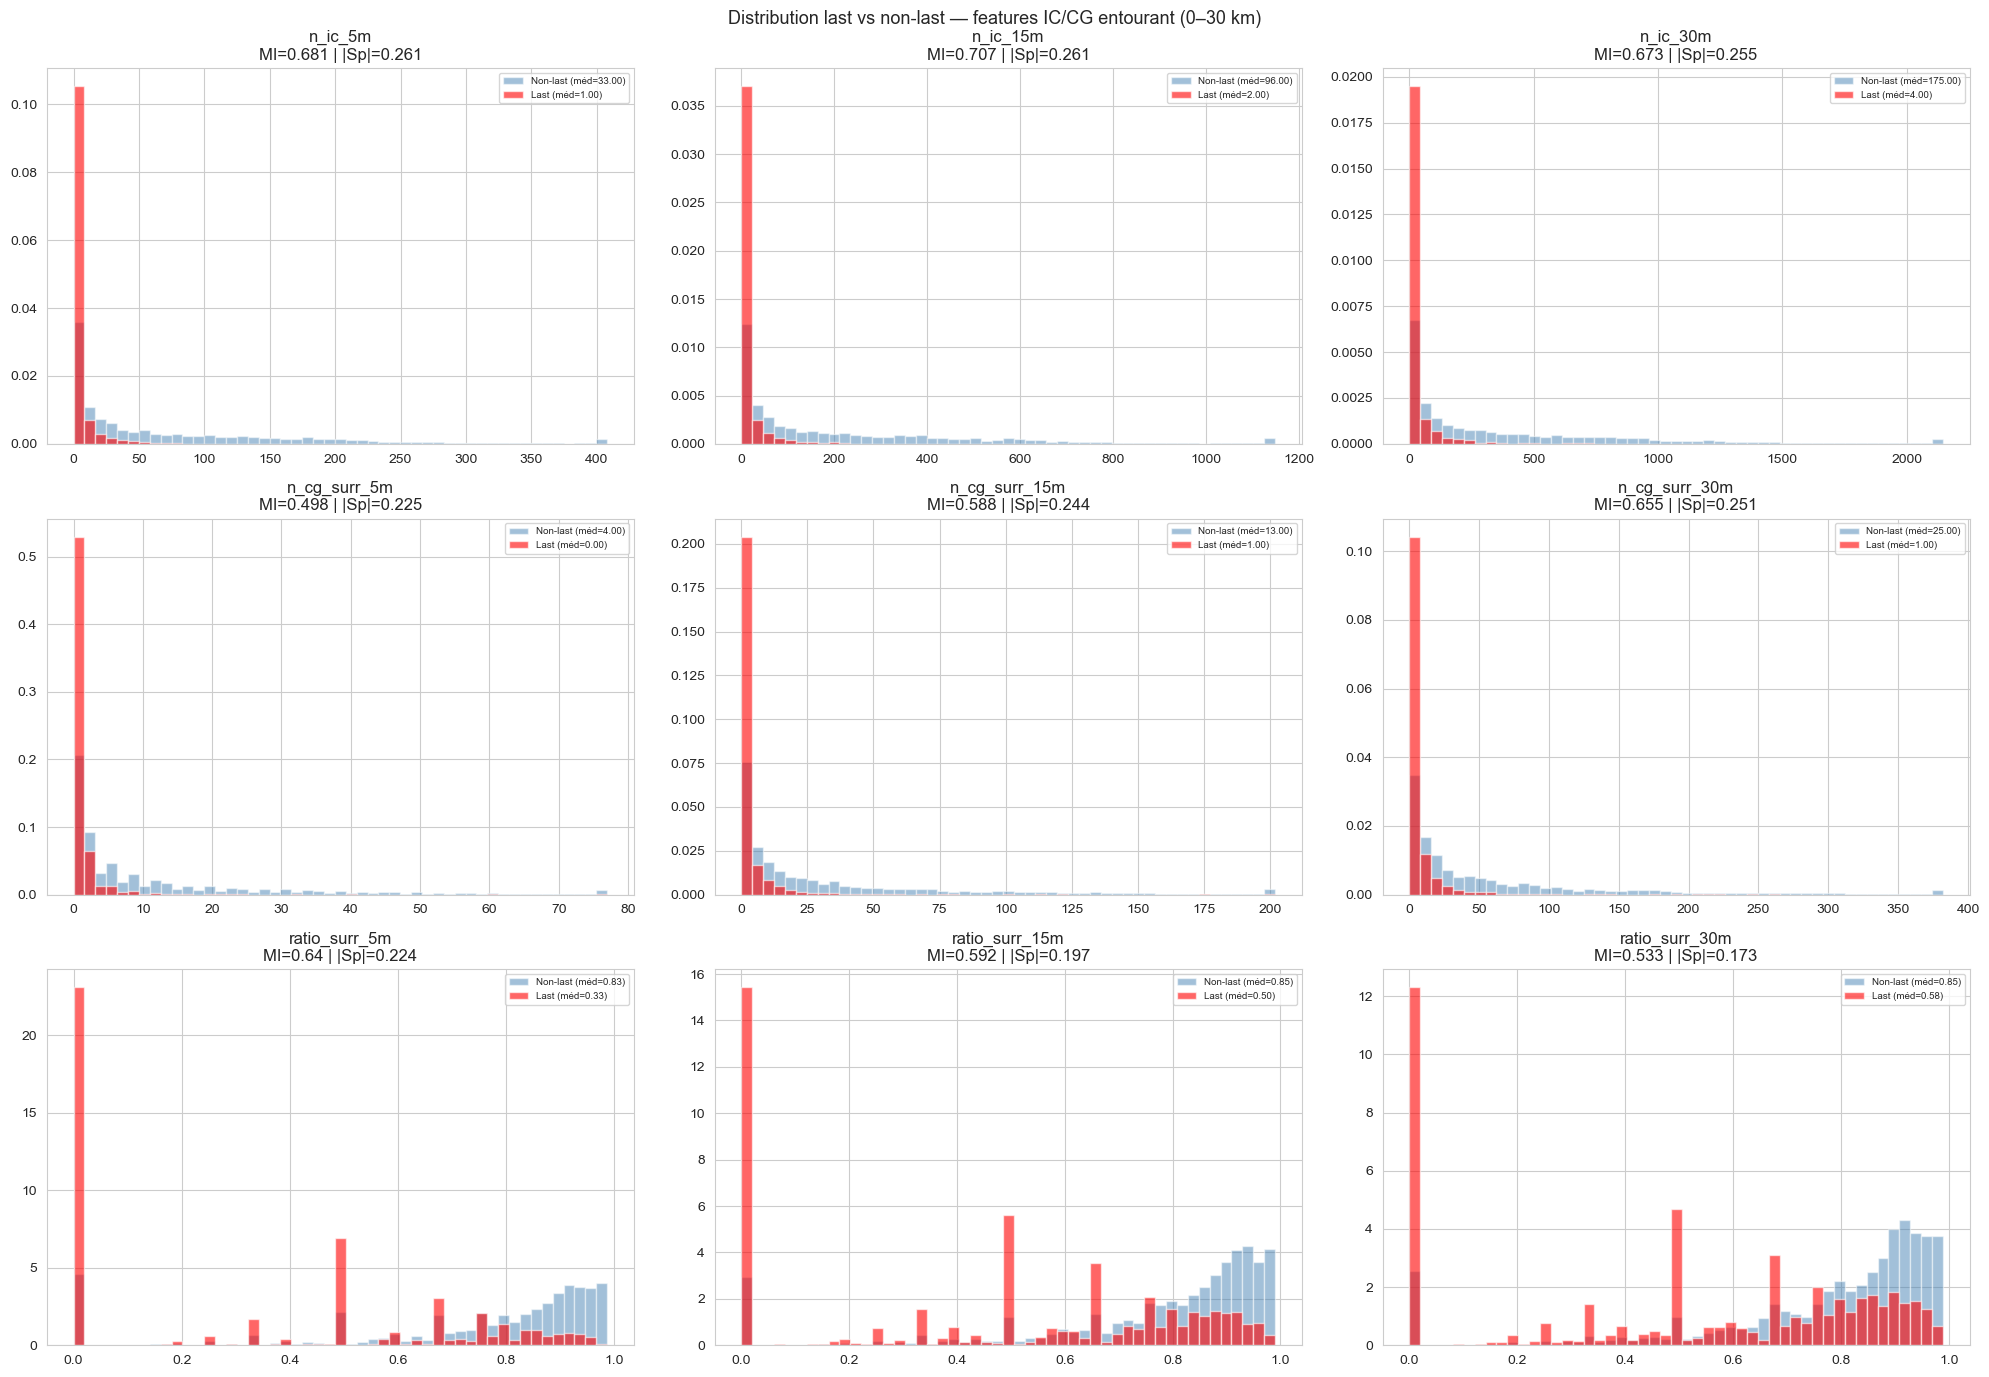

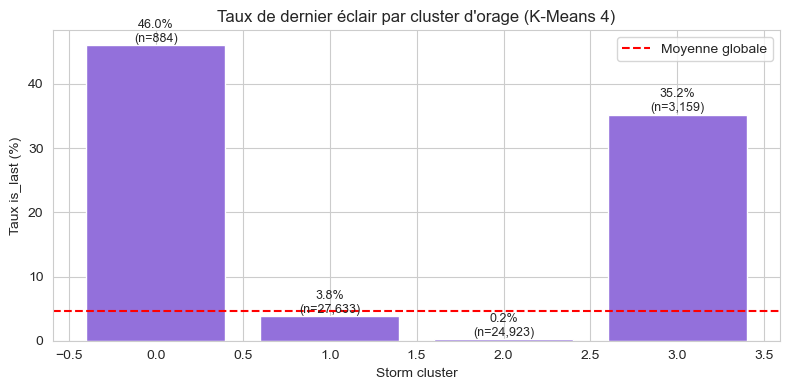


Détail par cluster :
               Taux last (%)  N éclairs
storm_cluster                          
0                      46.04        884
1                       3.81      27633
2                       0.22      24923
3                      35.20       3159


In [11]:
# ── Distributions last vs non-last — surrounding features ────────────────────
last_s     = df_surr_model[df_surr_model['target'] == 1]
non_last_s = df_surr_model[df_surr_model['target'] == 0]

surr_plot_feats = [
    'n_ic_5m', 'n_ic_15m', 'n_ic_30m',
    'n_cg_surr_5m', 'n_cg_surr_15m', 'n_cg_surr_30m',
    'ratio_surr_5m', 'ratio_surr_15m', 'ratio_surr_30m',
]

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(surr_plot_feats):
    q99 = df_surr_model[feat].quantile(0.99)
    q01 = df_surr_model[feat].quantile(0.01)
    bins = np.linspace(q01, q99, 50)
    axes[i].hist(non_last_s[feat].clip(q01, q99), bins=bins, alpha=0.5, color='steelblue',
                 density=True, label=f'Non-last (méd={non_last_s[feat].median():.2f})')
    axes[i].hist(last_s[feat].clip(q01, q99),     bins=bins, alpha=0.6, color='red',
                 density=True, label=f'Last (méd={last_s[feat].median():.2f})')
    mi_v  = round(float(mi_surr_norm.get(feat, 0)), 3)
    sp_v  = round(float(spearman_surr.get(feat, 0)), 3)
    axes[i].set_title(f'{feat}\nMI={mi_v} | |Sp|={sp_v}')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribution last vs non-last — features IC/CG entourant (0–30 km)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Storm cluster ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
cluster_rates = df_surr_model.groupby('storm_cluster')['target'].agg(['mean', 'count'])
cluster_rates.columns = ['Taux last (%)', 'N éclairs']
cluster_rates['Taux last (%)'] *= 100
bars = ax.bar(cluster_rates.index, cluster_rates['Taux last (%)'], color='mediumpurple', edgecolor='white')
ax.axhline(df_surr_model['target'].mean() * 100, color='red', linestyle='--', label='Moyenne globale')
ax.set_xlabel('Storm cluster')
ax.set_ylabel('Taux is_last (%)')
ax.set_title('Taux de dernier éclair par cluster d\'orage (K-Means 4)')
for bar, (_, row) in zip(bars, cluster_rates.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row["Taux last (%)"]:.1f}%\n(n={int(row["N éclairs"]):,})',
            ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()
print('\nDétail par cluster :')
print(cluster_rates.round(2))

### Interprétation — features IC/CG entourant & storm cluster

**Éclairs IC (n_ic_5m/15m/30m) — signal visuellement spectaculaire**
- n_ic_5m : non-last médiane=55, last médiane=1 → **55× moins d'IC au dernier éclair**. Distribution last concentrée à 0-5, non-last étalée jusqu'à 400. C'est la traduction directe de la physique : les IC se taisent en même temps que l'orage s'éteint.
- n_ic_15m et n_ic_30m : même pattern, ampleur comparable (médianes last = 2 et 4). La fenêtre 15m semble légèrement plus discriminante (MI=0.707) que 5m (MI=0.681), probablement plus stable.

**CG périphériques (n_cg_surr_5m/15m/30m)**
- n_cg_surr_30m MI=0.655 est le meilleur des trois. Non-last médiane=25.3, last médiane=1.03 → claire séparation. La longue fenêtre (30 min, 20-30 km) capte mieux l'activité résiduelle de la cellule.

**ratio_surr (IC/IC+CG) — signal attendu mais moins fort que prévu**
- ratio_surr_5m : non-last médiane=0.92, last médiane=0.33 → séparation visible. En fin d'alerte, le ratio IC baisse (moins d'IC, CG dominent ou tout s'arrête).
- ratio_surr_15m/30m : séparation moins nette (médianes qui se rapprochent). La fenêtre courte 5m donne le meilleur signal pour ce ratio.
- **Attention** : les distributions des ratio sont **bimodales** (pic à 0 et pic à 1) pour les deux classes → signal non-linéaire, bien capturé par les arbres.

**Storm cluster — signal le plus contrasté de tout le notebook**
- Cluster 0 (n=884, durée=4min, 1 CG) : **46%** last → alertes à éclair unique, presque toujours terminées au premier CG
- Cluster 3 (n=3,159, durée=6min, 2 CG) : **35.2%** last → alertes très courtes à 2 CG
- Cluster 1 (n=27,633, durée=55min, 25 CG) : **3.8%** last → alertes classiques
- Cluster 2 (n=24,923, durée=227min, 412 CG) : **0.2%** last → orages massifs, presque jamais à leur dernier CG

Le storm_cluster est un **prior d'alerte indispensable** : sans lui, le modèle confond systématiquement les alertes à éclair unique (46% de fin) avec les méga-orages (0.2% de fin). Le Spearman=0.027 confirme la relation non-linéaire (pas de gradient monotone).

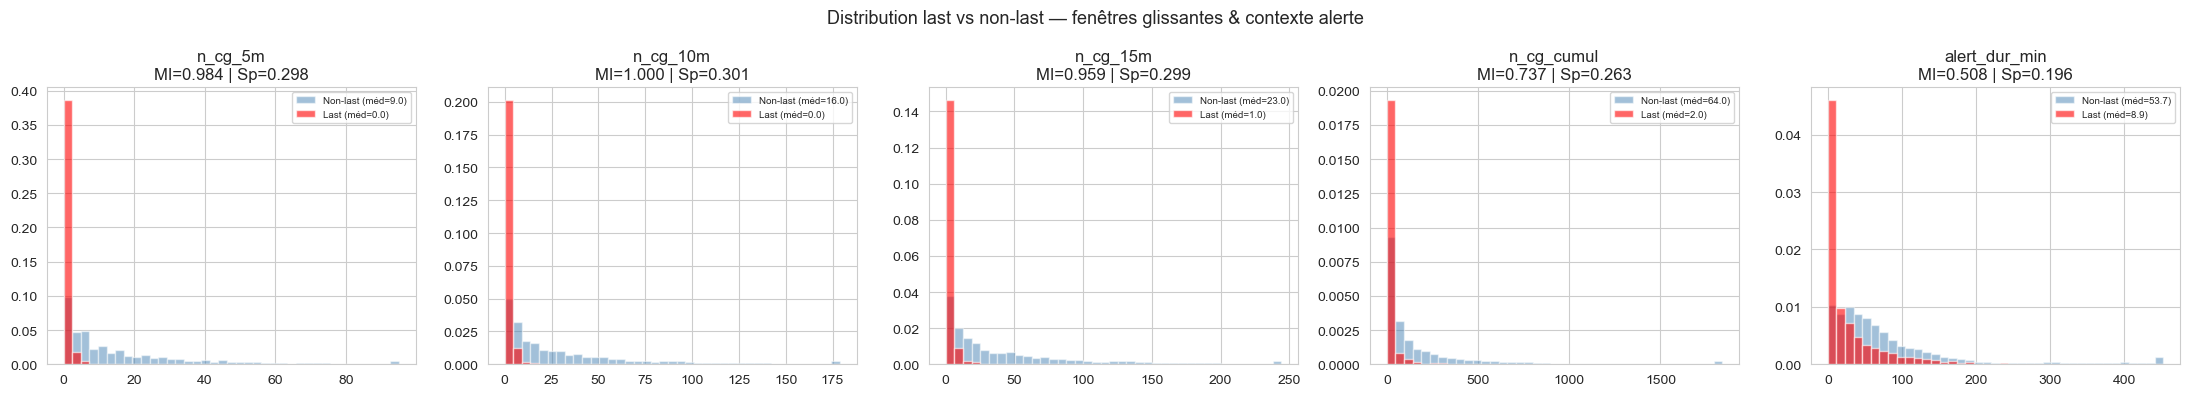

In [12]:
window_feats = ['n_cg_5m', 'n_cg_10m', 'n_cg_15m', 'n_cg_cumul', 'alert_dur_min']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i, feat in enumerate(window_feats):
    q99 = df_model[feat].quantile(0.99)
    bins = np.linspace(0, q99, 40)
    axes[i].hist(non_last[feat].clip(0, q99), bins=bins, alpha=0.5, color='steelblue',
                 density=True, label=f'Non-last (méd={non_last[feat].median():.1f})')
    axes[i].hist(last[feat].clip(0, q99),     bins=bins, alpha=0.6, color='red',
                 density=True, label=f'Last (méd={last[feat].median():.1f})')
    mi_val = mi_norm.get(feat, 0)
    sp_val = spearman.get(feat, 0)
    axes[i].set_title(f'{feat}\nMI={mi_val:.3f} | Sp={sp_val:.3f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribution last vs non-last — fenêtres glissantes & contexte alerte', fontsize=13)
plt.tight_layout()
plt.show()

### Interprétation — fenêtres glissantes & contexte alerte

- **n_cg_5m / n_cg_10m / n_cg_15m** : signal **quasi-déterministe** visuellement. La distribution "last" est un **pic vertical unique à 0** (médiane=0 pour les trois fenêtres). Non-last est étalé à droite (médianes 6, 18.5, 22 CG respectivement). Règle presque suffisante à elle seule : si aucun CG dans les 10 dernières minutes → probabilité de fin très élevée.
- **n_cg_cumul** : distribution très étalée pour non-last (médiane=64.5), dernier est concentré à gauche (médiane=2.0) → les derniers éclairs arrivent en début d'alerte (alertes courtes) ou après une longue série. Signal clair et complémentaire des fenêtres courtes.
- **alert_dur_min** : **résultat surprenant** — médiane last=8 min vs non-last=52.7 min. La majorité des derniers éclairs survient **tôt dans l'alerte** (< 30 min). Explication : les alertes courtes (clusters 0 et 3) contribuent massivement aux "last" avec des durées très courtes. Le modèle doit savoir que les alertes de < 10 min sont bien plus susceptibles de finir.

> **Note importante** : alert_dur_min et n_cg_cumul capturent ensemble le **profil de l'alerte** (courte/longue, intense/modérée) complémentaire des fenêtres glissantes qui capturent l'**activité immédiate**.

---
## 6. Comparaison features brutes vs dérivées — gain d'information

In [13]:
# Comparer la MI des features brutes (confirmées peu informatives en EDA)
# vs leurs features dérivées construites dans utils.py
# Note : dist et amplitude ne sont pas dans mi_norm (non inclus dans FEATURES)
# → on utilise des proxies : amp_abs pour amplitude brute
comparisons = [
    ('amplitude brute',  'amp_abs',      'Tendance amplitude', 'amp_abs_trend'),
    ('amplitude brute',  'amp_abs',      '% positifs cumul',  'pct_pos_cumul'),
    ('amplitude brute',  'amp_abs',      '% positifs 5 CG',   'pct_pos_last5'),
    ('inter_time brut',  'inter_time_s', 'Ratio médiane',      'ratio_median'),
    ('inter_time brut',  'inter_time_s', 'Ratio max',          'ratio_max'),
    ('inter_time brut',  'inter_time_s', 'Log inter-temps',    'inter_time_log'),
    ('inter_time brut',  'inter_time_s', 'Tendance inter',     'inter_trend'),
    ('inter_time brut',  'inter_time_s', 'Accél. inter',       'inter_accel'),
    ('n_cg_cumul brut',  'n_cg_cumul',   'n_cg_5m',            'n_cg_5m'),
    ('n_cg_cumul brut',  'n_cg_cumul',   'n_cg_10m',           'n_cg_10m'),
    ('dist_trend brut',  'dist_trend',   'Centroïde distance', 'centroid_dist_ap'),
    ('dist_trend brut',  'dist_trend',   'Centroïde approach', 'centroid_approach'),
]

rows = []
for label_brut, feat_brut, label_derive, feat_derive in comparisons:
    mi_brut   = float(mi_norm.get(feat_brut,   0))
    mi_derive = float(mi_norm.get(feat_derive, 0))
    rows.append({
        'Feature brute':   label_brut,
        'MI brute':        round(mi_brut,   4),
        'Feature dérivée': label_derive,
        'MI dérivée':      round(mi_derive, 4),
        'Gain MI':         round(mi_derive - mi_brut, 4),
    })

gain_df = pd.DataFrame(rows)
gain_df['Bilan'] = gain_df['Gain MI'].apply(
    lambda x: '✅ +gain' if x > 0.01 else ('➡ neutre' if x >= -0.01 else '❌ -perte'))
print("=== Gain d'information : brut → dérivé ===\n")
print(gain_df.to_string(index=False))

=== Gain d'information : brut → dérivé ===

  Feature brute  MI brute    Feature dérivée  MI dérivée  Gain MI    Bilan
amplitude brute    0.0751 Tendance amplitude      0.5623   0.4872  ✅ +gain
amplitude brute    0.0751   % positifs cumul      0.4989   0.4237  ✅ +gain
amplitude brute    0.0751    % positifs 5 CG      0.1088   0.0337  ✅ +gain
inter_time brut    0.7672      Ratio médiane      0.1171  -0.6501 ❌ -perte
inter_time brut    0.7672          Ratio max      0.0815  -0.6857 ❌ -perte
inter_time brut    0.7672    Log inter-temps      0.7600  -0.0072 ➡ neutre
inter_time brut    0.7672     Tendance inter      0.7606  -0.0067 ➡ neutre
inter_time brut    0.7672       Accél. inter      0.7043  -0.0629 ❌ -perte
n_cg_cumul brut    0.7367            n_cg_5m      0.9842   0.2475  ✅ +gain
n_cg_cumul brut    0.7367           n_cg_10m      1.0000   0.2633  ✅ +gain
dist_trend brut    0.5500 Centroïde distance      0.4589  -0.0911 ❌ -perte
dist_trend brut    0.5500 Centroïde approach      0.5751

### Interprétation — gain brut → dérivé

**Gains confirmés et physiquement justifiés :**
- `amp_abs` → `amp_abs_trend` : +0.49 MI → la **tendance** de l'amplitude encode un signal de déclin absent de la valeur instantanée. Attention : visuellement les distributions sont quasi identiques malgré ce gain.
- `n_cg_cumul` → `n_cg_5m/10m` : +0.25/+0.26 → les fenêtres **récentes** surpassent le cumul total. La clé est l'activité *immédiate*, pas l'historique global.
- `amp_abs` → `pct_pos_cumul` : +0.42 → la proportion cumulée de CG positifs accumule un signal de long terme invisible dans l'amplitude instantanée.

**Résultats contre-intuitifs — les ratios inter-temps nuisent :**
- `inter_time_s` → `ratio_median` : **-0.65** MI. Normaliser par la médiane historique détruit le signal. La valeur absolue du silence (en secondes) compte plus que sa comparaison au passé : 5 minutes de silence est un signal fort, que l'alerte ait commencé il y a 10 min ou 3 heures.
- `inter_time_s` → `inter_time_log` : neutre (-0.007) → la transformation log ne gagne ni ne perd d'information. Conserver pour la stabilité numérique des modèles linéaires.
- `dist_trend` → `centroid_dist_ap` : -0.09 → la position absolue du centroïde est moins informative que la tendance de la distance brute.

---
## 7. Matrice de corrélation entre features (redondance)

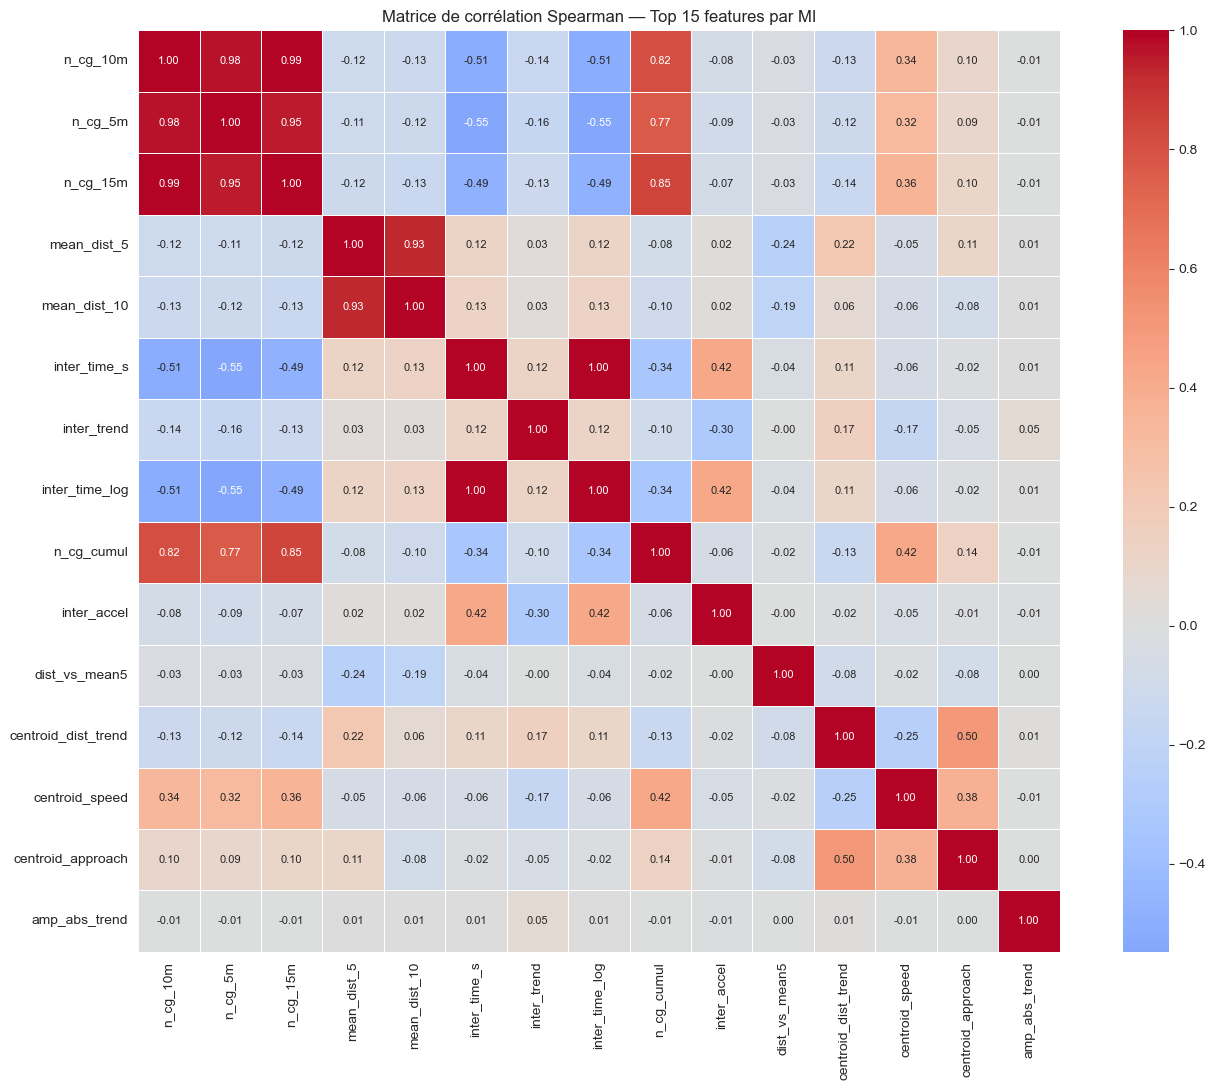

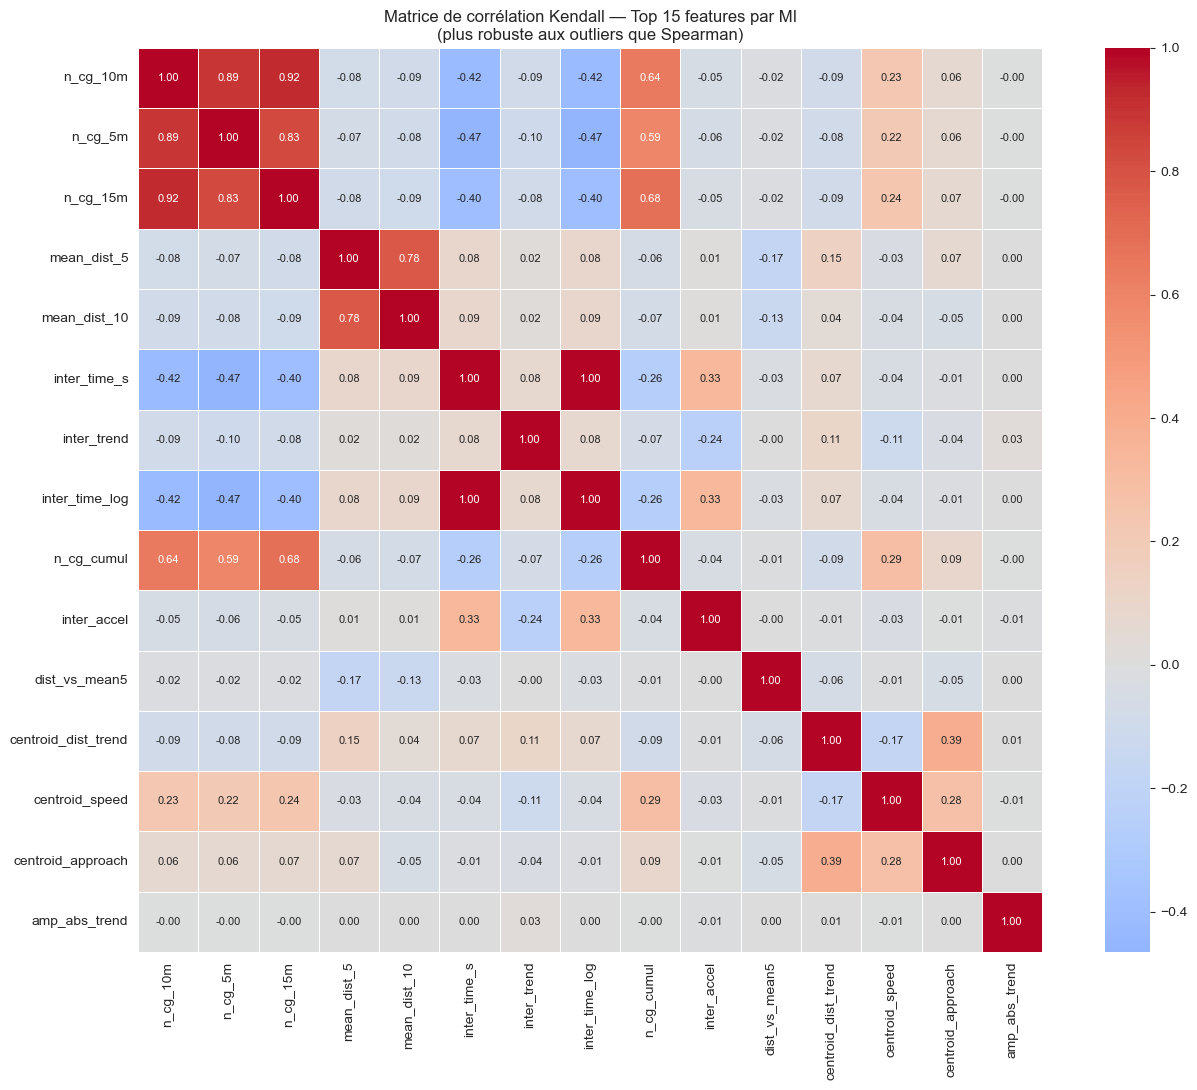

Paires fortement corrélées |Spearman| > 0.7 — candidats à la redondance :
  n_cg_10m                  ↔ n_cg_5m                    Sp=0.976  Kendall=0.888
  n_cg_10m                  ↔ n_cg_15m                   Sp=0.989  Kendall=0.925
  n_cg_10m                  ↔ n_cg_cumul                 Sp=0.815  Kendall=0.641
  n_cg_5m                   ↔ n_cg_15m                   Sp=0.954  Kendall=0.833
  n_cg_5m                   ↔ n_cg_cumul                 Sp=0.766  Kendall=0.586
  n_cg_15m                  ↔ n_cg_cumul                 Sp=0.849  Kendall=0.684
  mean_dist_5               ↔ mean_dist_10               Sp=0.928  Kendall=0.776
  inter_time_s              ↔ inter_time_log             Sp=1.000  Kendall=1.000


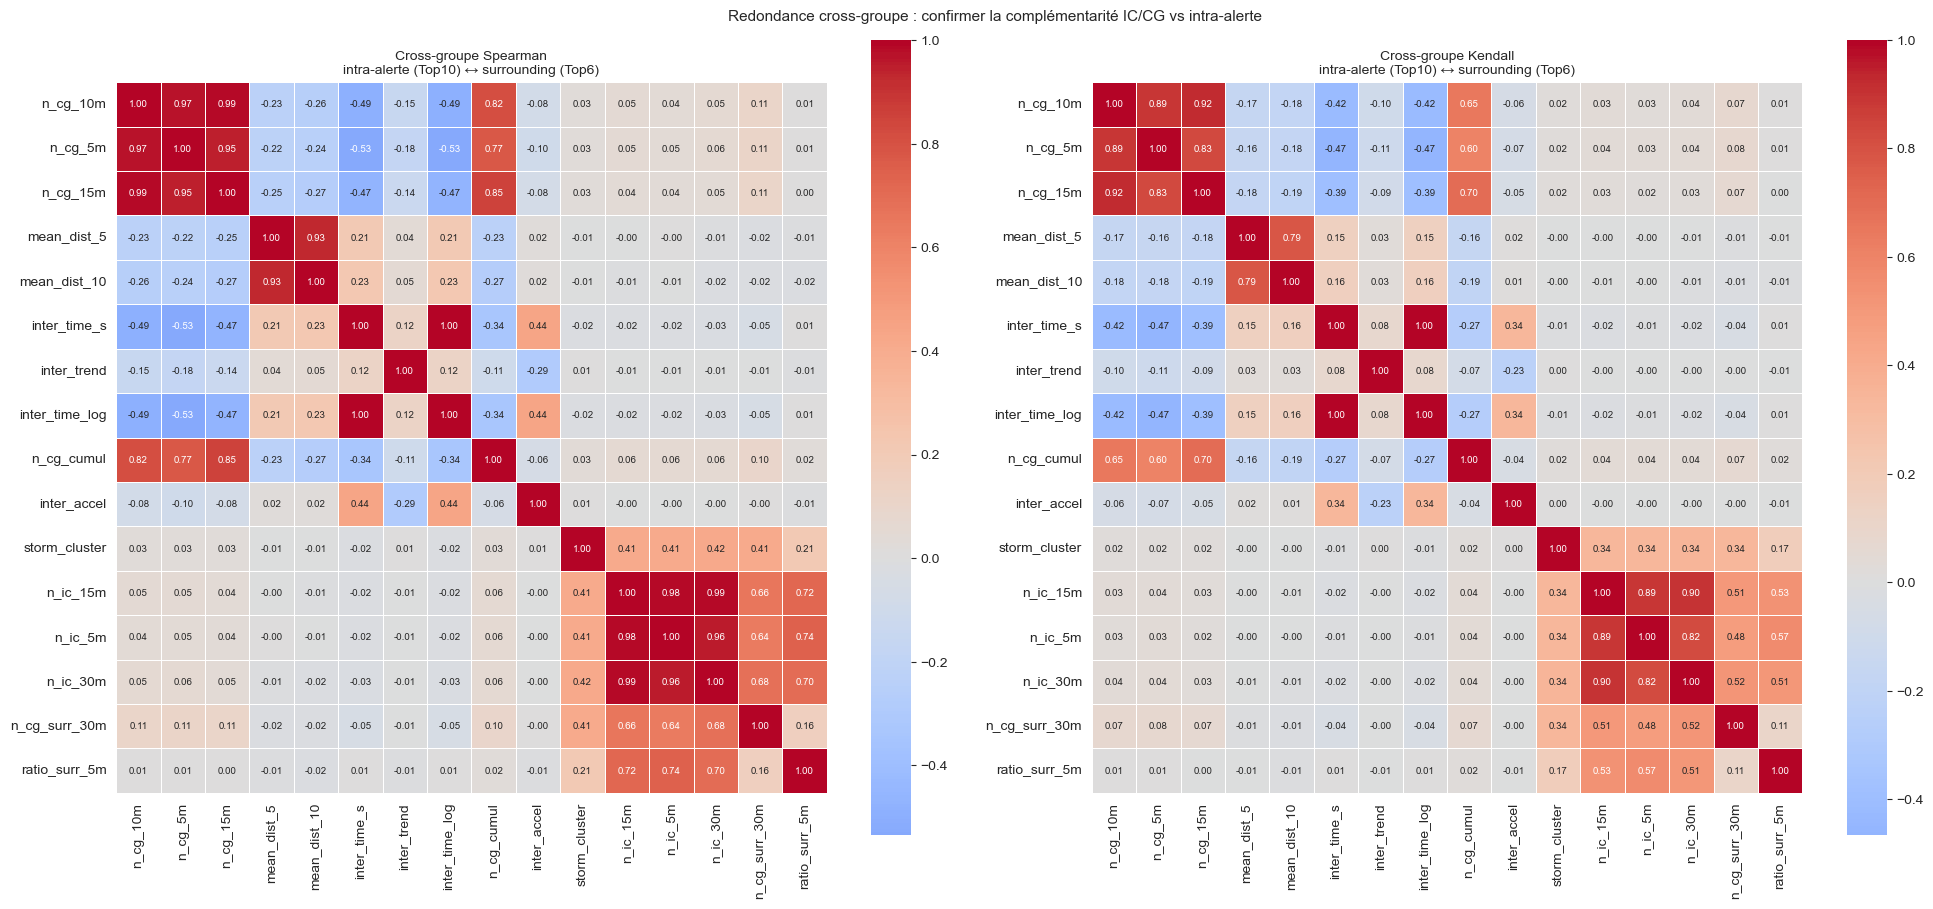

In [14]:
top_feats_list = mi_norm.head(15).index.tolist()

# ── Spearman ─────────────────────────────────────────────────────────────────
corr_sp = df_model[top_feats_list].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_sp, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Matrice de corrélation Spearman — Top 15 features par MI', fontsize=12)
plt.tight_layout()
plt.show()

# ── Kendall ───────────────────────────────────────────────────────────────────
corr_kt = df_model[top_feats_list].corr(method='kendall')

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_kt, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Matrice de corrélation Kendall — Top 15 features par MI\n(plus robuste aux outliers que Spearman)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Paires très corrélées (Spearman > 0.7) ───────────────────────────────────
print('Paires fortement corrélées |Spearman| > 0.7 — candidats à la redondance :')
found = False
for i in range(len(corr_sp)):
    for j in range(i+1, len(corr_sp)):
        sp_val = corr_sp.iloc[i, j]
        kt_val = corr_kt.iloc[i, j]
        if abs(sp_val) > 0.7:
            print(f'  {corr_sp.index[i]:25s} ↔ {corr_sp.columns[j]:25s}  Sp={sp_val:.3f}  Kendall={kt_val:.3f}')
            found = True
if not found:
    print('  Aucune paire > 0.7 dans le Top 15')

# ── Corrélation cross-groupe intra-alerte ↔ surrounding ──────────────────────
top_surr = mi_surr_norm.head(6).index.tolist()
df_all_top = df_model[top_feats_list[:10]].join(
    df_surr_model[top_surr].reset_index(drop=True), how='inner'
)
corr_cross_sp = df_all_top.corr(method='spearman')
corr_cross_kt = df_all_top.corr(method='kendall')

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
sns.heatmap(corr_cross_sp, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5, annot_kws={'size': 7})
axes[0].set_title('Cross-groupe Spearman\nintra-alerte (Top10) ↔ surrounding (Top6)', fontsize=10)

sns.heatmap(corr_cross_kt, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], square=True, linewidths=0.5, annot_kws={'size': 7})
axes[1].set_title('Cross-groupe Kendall\nintra-alerte (Top10) ↔ surrounding (Top6)', fontsize=10)
plt.suptitle('Redondance cross-groupe : confirmer la complémentarité IC/CG vs intra-alerte', fontsize=11)
plt.tight_layout()
plt.show()

### Interprétation — redondances (Spearman + Kendall)

> Kendall τ est plus robuste aux outliers et aux distributions à queues lourdes que Spearman ρ. Sur des données non-gaussiennes comme les inter-temps ou les comptages d'éclairs, il est souvent plus fiable. En général |Kendall| ≈ 0.67 × |Spearman| pour une relation monotone pure.

**Paires quasi-identiques (Spearman > 0.95) — confirmées par Kendall :**
- `n_cg_5m ↔ n_cg_10m ↔ n_cg_15m` (Sp 0.95–0.99, Kendall ~0.80–0.90) : les trois fenêtres mesurent pratiquement la même chose. Pour un modèle linéaire, conserver **uniquement n_cg_10m** (meilleure MI). Pour LightGBM/XGBoost, les trois coexistent utilement car ils partitionnent sur des seuils différents.
- `inter_time_s ↔ inter_time_log` (Sp=1.000, Kendall=1.000) : strictement redondants. Conserver **inter_time_log** uniquement.

**Paires fortement corrélées (Sp 0.77–0.93) :**
- `mean_dist_5 ↔ mean_dist_10` (Sp=0.928) → quasi-redondants. Préférer mean_dist_5 (MI légèrement supérieure).
- `n_cg_cumul ↔ n_cg_10m` (Sp=0.815) → corrélation forte mais n_cg_cumul encode la **taille totale** de l'alerte absente des fenêtres courtes → conserver les deux.

**Indépendance cross-groupes (intra-alerte ↔ surrounding) :**
- Les features IC/CG entourant (n_ic_*, n_cg_surr_*) mesurent l'activité **hors zone alerte** (20–30 km), donc structurellement complémentaires aux features intra-alerte. Vérifier les heatmaps cross-groupe : si les corrélations sont < 0.4, les surrounding features apportent une information orthogonale.

---
## 8. Synthèse

In [15]:
print('=== SYNTHÈSE COMPLÈTE — Features à retenir pour la modélisation ===\n')

SEUIL_MI = 0.05  # seuil minimal MI normalisée (sur features intra-alerte)

retenues = mi_norm[mi_norm >= SEUIL_MI].sort_values(ascending=False)
ecartees = mi_norm[mi_norm <  SEUIL_MI].sort_values(ascending=False)

print(f'── FEATURES INTRA-ALERTE (compute_features) ──────────────────────────')
print(f'Retenues (MI >= {SEUIL_MI}) : {len(retenues)}')
for f, v in retenues.items():
    sp_v = spearman.get(f, 0)
    print(f'  {f:30s}  MI={v:.4f}  |Sp|={sp_v:.4f}')

print(f'\nÉcartées (MI < {SEUIL_MI}) : {len(ecartees)}')
for f, v in ecartees.items():
    print(f'  {f:30s}  MI={v:.4f}')

# Surrounding features (normalisées sur leur propre max)
SEUIL_SURR = 0.1
retenues_surr = mi_surr_norm[mi_surr_norm >= SEUIL_SURR].sort_values(ascending=False)
ecartees_surr = mi_surr_norm[mi_surr_norm <  SEUIL_SURR].sort_values(ascending=False)

print(f'\n── FEATURES ENTOURANT + CLUSTER (compute_surrounding_features / cluster_storms) ──')
print(f'Retenues (MI_norm >= {SEUIL_SURR}) : {len(retenues_surr)}')
for f, v in retenues_surr.items():
    sp_v = spearman_surr.get(f, 0)
    print(f'  {f:30s}  MI_norm={v:.4f}  |Sp|={sp_v:.4f}')
print(f'\nÉcartées : {len(ecartees_surr)}')
for f, v in ecartees_surr.items():
    print(f'  {f:30s}  MI_norm={v:.4f}')

print('\n── RECOMMANDATIONS ─────────────────────────────────────────────────────')
print("""
FEATURES CLÉS (conserver absolument) :
  [Activité récente]  n_cg_5m, n_cg_10m, n_cg_15m → Signal le plus fort (MI~1.0)
                       Un silence récent = plus aucun CG dans les 5-15 min → fin probable
  [Distance]          mean_dist_5, mean_dist_10 → Contexte spatial : là où frappe l'orage
  [Inter-temps]       inter_time_s/log, inter_trend, inter_accel → Allongement du silence
  [Contexte alerte]   n_cg_cumul, alert_dur_min → Durée et intensité cumulative
  [Centroïde]         centroid_dist_trend, centroid_speed → Déplacement du cœur orageux

FEATURES À SURVEILLER (MI modérée, non-linéaires) :
  [Amplitude]         amp_abs_trend, amp_trend, pct_pos_cumul → Déclin d'intensité
  [Centroïde]         centroid_approach, centroid_dist_ap → Éloignement de l'aéroport
  [Ratios inter]      z_score_inter > ratio_median > ratio_mean > ratio_max (MI faible)

FEATURES FAIBLES (envisager l'exclusion) :
  hour, airport_enc, is_positive, ratio_max, ratio_mean, ratio_median
  → MI < 0.15 et |Spearman| < 0.04 → peu de signal discriminant

FEATURES ENTOURANT (à inclure si temps de calcul acceptable) :
  → Analyser les résultats de la section 5b pour confirmer
  → ratio_surr_{w}m (signal physique IC/CG fort mais fenêtre à optimiser)
  → n_ic_30m probablement plus stable que 5m (plus de signal sur longue fenêtre)
""")

=== SYNTHÈSE COMPLÈTE — Features à retenir pour la modélisation ===

── FEATURES INTRA-ALERTE (compute_features) ──────────────────────────
Retenues (MI >= 0.05) : 32
  n_cg_10m                        MI=1.0000  |Sp|=0.3009
  n_cg_5m                         MI=0.9842  |Sp|=0.2984
  n_cg_15m                        MI=0.9592  |Sp|=0.2988
  mean_dist_5                     MI=0.8960  |Sp|=0.0921
  mean_dist_10                    MI=0.8896  |Sp|=0.0945
  inter_time_s                    MI=0.7672  |Sp|=0.0488
  inter_trend                     MI=0.7606  |Sp|=0.0649
  inter_time_log                  MI=0.7600  |Sp|=0.0488
  n_cg_cumul                      MI=0.7367  |Sp|=0.2628
  inter_accel                     MI=0.7043  |Sp|=0.0700
  dist_vs_mean5                   MI=0.6370  |Sp|=0.1405
  centroid_dist_trend             MI=0.6275  |Sp|=0.0536
  centroid_speed                  MI=0.5797  |Sp|=0.1888
  centroid_approach               MI=0.5751  |Sp|=0.0340
  amp_abs_trend                   M